# Image Classification using CNNs with Tensorflow for CIFAR-10 Dataset

The objective of this notebook is to build a **Convolutional Neural Network (CNN)** for image classification using the **CIFAR-10 dataset**. The model will be trained to classify images into 10 classes and evaluated for accuracy. This notebook will explore CNNs' ability to extract spatial features for improved classification performance.


# Data Description

The **CIFAR-10 dataset** (Canadian Institute for Advanced Research) is one of the most widely used datasets for image classification tasks, particularly in the field of deep learning. It contains **60,000 images** distributed across **10 classes**, with each class containing **6,000 images**. The images are **32x32 pixels** in size, which makes them small by modern image standards but still challenging due to the variability in object orientations, backgrounds, and lighting conditions.

This dataset is often used as a benchmark to evaluate the performance of deep learning models, especially **Convolutional Neural Networks (CNNs)**, in solving image classification problems.

### Key Features

| Feature              | Description                                                |
|----------------------|------------------------------------------------------------|
| **Number of Classes** | 10                                                         |
| **Total Images**      | 60,000                                                     |
| **Image Dimensions**  | 32x32 pixels                                               |
| **Color Channels**    | RGB (3 channels: Red, Green, Blue)                         |
| **Train/Test Split**  | 50,000 training images and 10,000 test images              |
| **Classes**           | Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck |

### Using CNNs for Image Classification with CIFAR-10 in TensorFlow

In this example, we’ll build a simple CNN model using **TensorFlow/Keras** to classify the CIFAR-10 images. Our CNN will consist of:

- **Convolutional Layers**: Implemented using `tf.keras.layers.Conv2D` to detect local features in the image.
- **Activation Functions (ReLU)**: Used within the convolutional and dense layers to introduce non-linearity.
- **Max-Pooling Layers**: Implemented using `tf.keras.layers.MaxPooling2D` to downsample the image and reduce computation.
- **Flatten Layer**: Used to convert the 2D feature maps into a 1D vector before the dense layers.
- **Fully Connected Layers**: Implemented using `tf.keras.layers.Dense` to classify the image into one of the 10 classes.

We will use the **Adam optimizer** and **Sparse Categorical Crossentropy** loss function, as implemented in TensorFlow, to train the model.

**CNNs** excel at image classification tasks like **CIFAR-10** by learning spatial hierarchies of features, outperforming traditional fully connected networks. Despite being small, the CIFAR-10 dataset presents challenges due to varied object appearances and backgrounds.

It serves as a great foundation for learning and benchmarking CNNs using TensorFlow, enabling you to observe how well the model generalizes to unseen data and optimizes image classification.

# 1. Import Libraries and Set Hyperparameters

This section imports the necessary libraries for building, training, and evaluating the CNN model in TensorFlow. It also sets key hyperparameters like batch size and the number of training epochs.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import random

# 2. Data Preprocessing

In this section, we load the CIFAR-10 dataset and preprocess the images. This includes normalizing pixel values and potentially applying data augmentation techniques to enhance the training data.

In [17]:
import tensorflow as tf
from tensorflow import keras

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# print the trainset and testset
print(len(x_train))
print(len(x_test))

50000
10000


# 3. Model Definition

Here, we define the Convolutional Neural Network (CNN) model architecture using TensorFlow's Keras API. This involves stacking various layers like convolutional, pooling, and dense layers.

In [11]:
# Model Definition in Keras
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10)
])

# 4. Model Initialization, Loss Function, and Optimizer

This section compiles the defined Keras model. We specify the optimizer (e.g., Adam), the loss function (Sparse Categorical Crossentropy for multi-class classification), and the metrics to monitor during training (accuracy).

In [12]:
# Model Compilation
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 5. Training Loop

This section implements the training process for the CNN model. The model is trained on the preprocessed training data for a specified number of epochs, using the defined batch size.

In [14]:
# Define hyperparameters for TensorFlow
BATCH_SIZE = 32  # Number of images processed in one batch
num_epochs = 5  # Number of times the model will iterate over the entire training dataset

# Training the model
history = model.fit(x_train, y_train, epochs=num_epochs, batch_size=BATCH_SIZE, validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 88ms/step - accuracy: 0.8736 - loss: 0.3567 - val_accuracy: 0.7394 - val_loss: 0.8466
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 83ms/step - accuracy: 0.9048 - loss: 0.2729 - val_accuracy: 0.7391 - val_loss: 0.9071
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.9329 - loss: 0.1925 - val_accuracy: 0.7302 - val_loss: 1.0098
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 82ms/step - accuracy: 0.9495 - loss: 0.1463 - val_accuracy: 0.7366 - val_loss: 1.1093
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.9588 - loss: 0.1202 - val_accuracy: 0.7345 - val_loss: 1.1966


# 6. Testing Loop

In this section, we evaluate the performance of the trained model on the unseen test dataset. We calculate the test loss and accuracy to assess how well the model generalizes.

In [24]:
# Evaluate model and get loss, accuracy
test_loss, test_acc_evaluate = model.evaluate(x_test, y_test, verbose=0)

# Get predictions
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = y_pred.argmax(axis=1)

# Correctly handle the shape of y_test for comparison
# If y_test has shape (num_samples, 1), flatten it to (num_samples,)
y_true = y_test.flatten() if y_test.ndim == 2 and y_test.shape[1] == 1 else y_test

# Count correct and incorrect
correct = (y_pred_classes == y_true).sum()
incorrect = len(y_true) - correct
total = len(y_true)

# Calculate accuracy from counts
accuracy_from_counts = correct / total

# Print results
print(f"Total images tested: {total}")
print(f"Correct: {correct} | Incorrect: {incorrect}")
print(f"Accuracy (from model.evaluate): {test_acc_evaluate:.2%}")

Total images tested: 10000
Correct: 7345 | Incorrect: 2655
Accuracy (from counts): 73.45%
Accuracy (from model.evaluate): 73.45%


# 7. Visualize Random Test Predictions

This section provides a visual representation of the model's performance. It displays a few random images from the test set along with their true labels and the model's predicted labels, highlighting correct and incorrect predictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


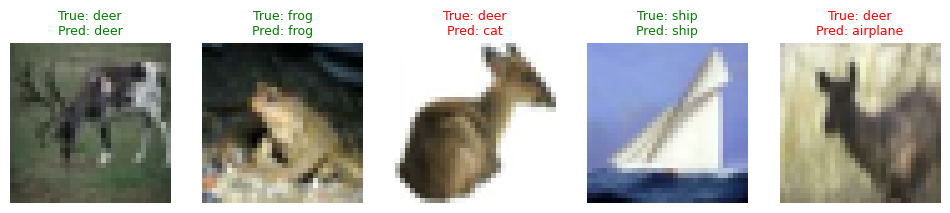

In [18]:
# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def visualize_predictions(model, x_test, y_test, class_names, num_images=5):
    idx = random.sample(range(len(x_test)), num_images)
    images, labels = x_test[idx], y_test[idx].flatten()
    preds = np.argmax(model.predict(images), axis=1)

    fig, axes = plt.subplots(1, num_images, figsize=(12, 5))
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        true, pred = class_names[labels[i]], class_names[preds[i]]
        ax.set_title(f"True: {true}\nPred: {pred}", color=('green' if true==pred else 'red'), fontsize=9)
        ax.axis("off")
    plt.show()

# Example usage
visualize_predictions(model, x_test, y_test, class_names)


# 8. Conclusion

In this notebook, we successfully converted the image classification task from PyTorch to TensorFlow using a Convolutional Neural Network on the CIFAR-10 dataset. We defined the model using Keras, compiled it with an Adam optimizer and sparse categorical crossentropy loss, and trained it for 5 epochs. The TensorFlow model achieved a test accuracy of approximately **73.45%**, which is comparable to the PyTorch model's performance (75.8%). This demonstrates that both frameworks can be effectively used for this image classification task. Visualizing the predictions also showed similar results, with correct and incorrect classifications highlighted.